# V2

In [21]:
# ==============================================================================
# Cell 1: Mount Drive & Imports (Colab-Safe)
# ==============================================================================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Install only what's missing (Colab has most packages pre-installed)
!pip install albumentations -q 2>/dev/null

import os, sys, gc, numpy as np, pandas as pd, matplotlib.pyplot as plt
from tqdm import tqdm

# PyTorch
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# SAR + Vector handling
import rasterio
from rasterio.features import rasterize
import geopandas as gpd

# Augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [6]:
# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {DEVICE}")
print(f"✅ PyTorch: {torch.__version__} | rasterio: {rasterio.__version__} | geopandas: {gpd.__version__}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Using device: cpu
✅ PyTorch: 2.10.0+cpu | rasterio: 1.5.0 | geopandas: 1.1.3


In [22]:
# ==============================================================================
# Cell 2: Configuration (Your Specs)
# ==============================================================================
class Config:
    DATA_DIR = "/content/drive/MyDrive/SAR_water_images_and_labels"
    OUTPUT_DIR = "/content/drive/MyDrive/SAR_water_images_and_labels/outputs_for_ViT_2"

    # Your actual folder structure
    TRAIN_IMAGES = os.path.join(DATA_DIR, "images")
    TRAIN_MASKS  = os.path.join(DATA_DIR, "labels")  # Contains .shp files
    VAL_IMAGES   = os.path.join(DATA_DIR, "images")
    VAL_MASKS    = os.path.join(DATA_DIR, "labels")
    TEST_IMAGES  = os.path.join(DATA_DIR, "images")
    GROUND_TRUTH = os.path.join(DATA_DIR, "labels")

    # Your requested parameters
    IMG_SIZE = 512
    IN_CHANNELS = 2  # SAR dual-pol
    OUT_CHANNELS = 1
    INIT_FEATURES = 64

    BATCH_SIZE = 2
    ACCUMULATE_STEPS = 4  # Effective batch = 8
    NUM_EPOCHS = 100
    LEARNING_RATE = 1e-2  # Your requested LR
    WEIGHT_DECAY = 1e-5

    LR_PATIENCE = 5
    LR_FACTOR = 0.5
    LR_MIN = 1e-7
    EARLY_STOP_PATIENCE = 15
    USE_AMP = True
    AUGMENT = True
    SAVE_BEST_ONLY = True

config = Config()

# Create output directories
for d in ["", "checkpoints_ViT_2", "metrics_ViT_2", "predictions_ViT_2"]:
    os.makedirs(os.path.join(config.OUTPUT_DIR, d), exist_ok=True)

print(f"✅ Configuration loaded | Output: {config.OUTPUT_DIR}")

✅ Configuration loaded | Output: /content/drive/MyDrive/SAR_water_images_and_labels/outputs_for_ViT_2


In [23]:
# ==============================================================================
# Cell 3: SAR-Safe Augmentation (Fixed for albumentations>=1.4)
# ==============================================================================
def get_training_augmentation():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        # Use Affine instead of deprecated ShiftScaleRotate
        A.Affine(translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},
                 scale={"x": (0.9, 1.1), "y": (0.9, 1.1)},
                 rotate=(-15, 15), p=0.5),
        A.OneOf([
            A.GaussNoise(std_dev_range=(0.1, 0.3), p=1),  # Fixed parameter name
            A.GaussianBlur(blur_limit=(3, 7), p=1),
        ], p=0.3),
        # SAR-safe normalization
        A.Normalize(mean=(0.5, 0.5), std=(0.5, 0.5)),
        ToTensorV2()
    ])

def get_validation_augmentation():
    return A.Compose([
        A.Normalize(mean=(0.5, 0.5), std=(0.5, 0.5)),
        ToTensorV2()
    ])

print("✅ Augmentation pipelines defined (albumentations-compatible)")

✅ Augmentation pipelines defined (albumentations-compatible)


In [24]:
# ==============================================================================
# Cell 4: Dataset Class (Shapefile → Raster Mask Conversion)
# ==============================================================================
class SARWaterDataset(Dataset):
    def __init__(self, image_dir, mask_dir, file_list=None, transform=None, in_channels=2, img_size=512):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.in_channels = in_channels
        self.img_size = img_size

        if file_list is None:
            self.files = sorted([f for f in os.listdir(image_dir)
                               if f.lower().endswith(('.tif', '.tiff', '.png', '.jpg', '.jpeg'))])
        else:
            self.files = file_list

        # Pre-scan for shapefiles (look for .shp extension)
        if os.path.exists(mask_dir):
            self.available_shapes = {os.path.splitext(f)[0]: f
                                   for f in os.listdir(mask_dir)
                                   if f.lower().endswith('.shp')}
        else:
            self.available_shapes = {}
            print(f"⚠️ Mask directory not found: {mask_dir}")

    def __len__(self):
        return len(self.files)

    def _rasterize_shapefile(self, shp_path, reference_raster):
        """Convert vector shapefile to binary raster mask matching reference image"""
        try:
            # Read shapefile
            gdf = gpd.read_file(shp_path)

            # Ensure same CRS as reference raster
            if gdf.crs != reference_raster.crs:
                gdf = gdf.to_crs(reference_raster.crs)

            # Rasterize: polygons → binary mask
            mask = rasterize(
                shapes=[(geom, 1) for geom in gdf.geometry if geom is not None],
                out_shape=(reference_raster.height, reference_raster.width),
                transform=reference_raster.transform,
                fill=0,  # Background = 0 (non-water)
                dtype='uint8'
            )
            return mask.astype(np.float32)
        except Exception as e:
            print(f"⚠️ Failed to rasterize {shp_path}: {e}")
            # Return empty mask as fallback
            return np.zeros((reference_raster.height, reference_raster.width), dtype=np.float32)

    def __getitem__(self, idx):
        img_name = self.files[idx]
        img_path = os.path.join(self.image_dir, img_name)

        # Load SAR image
        with rasterio.open(img_path) as src:
            # Read exactly IN_CHANNELS bands (2 for SAR)
            bands = list(range(1, self.in_channels + 1))
            image = src.read(bands).transpose(1, 2, 0).astype(np.float32)

            # Normalize to [0, 1] if needed
            if image.max() > 1.0:
                image = image / 255.0

            # Store transform/CRS for mask rasterization
            ref_transform = src.transform
            ref_crs = src.crs
            ref_shape = (src.height, src.width)

        # Find corresponding shapefile
        base_name = os.path.splitext(img_name)[0]
        shp_filename = self.available_shapes.get(base_name)

        if shp_filename:
            shp_path = os.path.join(self.mask_dir, shp_filename)
            mask = self._rasterize_shapefile(shp_path,
                                           type('RasterRef', (), {
                                               'transform': ref_transform,
                                               'crs': ref_crs,
                                               'height': ref_shape[0],
                                               'width': ref_shape[1]
                                           })())
        else:
            # Fallback: empty mask (for debugging)
            print(f"⚠️ No shapefile found for {img_name}, using empty mask")
            mask = np.zeros(ref_shape, dtype=np.float32)

        # Resize image and mask to IMG_SIZE if needed
        if image.shape[0] != self.img_size or image.shape[1] != self.img_size:
            from skimage.transform import resize
            image = resize(image, (self.img_size, self.img_size, self.in_channels),
                          mode='reflect', anti_aliasing=True, preserve_range=True).astype(np.float32)
            mask = resize(mask, (self.img_size, self.img_size),
                         order=0, mode='reflect', anti_aliasing=False, preserve_range=True).astype(np.float32)
            mask = (mask > 0.5).astype(np.float32)  # Re-binarize after resize

        # Apply transforms
        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image, mask = transformed['image'], transformed['mask']

        # Ensure mask has channel dimension
        if mask.dim() == 2:
            mask = mask.unsqueeze(0)

        return image, mask

print("✅ Dataset class defined (shapefile → raster conversion)")

✅ Dataset class defined (shapefile → raster conversion)


In [25]:
# ==============================================================================
# Cell 5: ViT Model Architecture (Unchanged - Already Correct)
# ==============================================================================
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=256, patch_size=16, in_channels=3, embed_dim=256):
        super().__init__()
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)

class Attention(nn.Module):
    def __init__(self, dim, num_heads=8, qkv_bias=True, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)
    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        return self.proj_drop(self.proj(x))

class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads=8, mlp_ratio=4., qkv_bias=True, drop=0., attn_drop=0.):
        super().__init__()
        self.norm1, self.norm2 = nn.LayerNorm(dim), nn.LayerNorm(dim)
        self.attn = Attention(dim, num_heads, qkv_bias, attn_drop, drop)
        mlp_hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(dim, mlp_hidden), nn.GELU(), nn.Dropout(drop), nn.Linear(mlp_hidden, dim), nn.Dropout(drop))
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class ViTEncoder(nn.Module):
    def __init__(self, img_size=256, patch_size=16, in_channels=3, embed_dim=256, depth=6, num_heads=8):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        self.pos_embed = nn.Parameter(torch.zeros(1, (img_size // patch_size) ** 2, embed_dim))
        self.blocks = nn.ModuleList([TransformerBlock(embed_dim, num_heads, mlp_ratio=4.0) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.pos_embed.data.normal_(mean=0.0, std=0.02)
    def forward(self, x):
        x = self.patch_embed(x) + self.pos_embed
        for blk in self.blocks: x = blk(x)
        return self.norm(x)

class ViTSegmentation(nn.Module):
    def __init__(self, img_size=256, patch_size=16, in_channels=3, num_classes=1,
                 embed_dim=256, depth=6, num_heads=8):
        super().__init__()
        self.img_size = img_size
        self.encoder = ViTEncoder(img_size, patch_size, in_channels, embed_dim, depth, num_heads)
        self.head = nn.Sequential(
            nn.Conv2d(embed_dim, 128, 3, padding=1), nn.BatchNorm2d(128), nn.GELU(),
            nn.Conv2d(128, 64, 3, padding=1), nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, num_classes, 1)
        )
    def forward(self, x):
        B = x.shape[0]
        x = self.encoder(x)
        H = W = self.img_size // 16
        x = x.transpose(1, 2).reshape(B, -1, H, W)
        x = self.head(x)
        return F.interpolate(x, size=(self.img_size, self.img_size), mode='bilinear', align_corners=True)

print("✅ ViT Segmentation model defined")

✅ ViT Segmentation model defined


In [26]:
# ==============================================================================
# Cell 6: Loss & Metrics (Unchanged)
# ==============================================================================
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0): super().__init__(); self.smooth = smooth
    def forward(self, preds, targets):
        preds = torch.sigmoid(preds).view(-1)
        targets = targets.view(-1)
        inter = (preds * targets).sum()
        return 1 - (2. * inter + self.smooth) / (preds.sum() + targets.sum() + self.smooth)

class BCEDiceLoss(nn.Module):
    def __init__(self, bce_w=0.5, dice_w=0.5):
        super().__init__()
        self.bce_w, self.dice_w = bce_w, dice_w
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
    def forward(self, preds, targets):
        return self.bce_w * self.bce(preds, targets) + self.dice_w * self.dice(preds, targets)

def calculate_metrics(preds, targets, threshold=0.5):
    if preds.min() < 0 or preds.max() > 1: preds = torch.sigmoid(preds)
    p_bin = (preds > threshold).float().view(-1)
    t = targets.view(-1)
    tp, fp, fn, tn = (p_bin*t).sum(), (p_bin*(1-t)).sum(), ((1-p_bin)*t).sum(), ((1-p_bin)*(1-t)).sum()
    s = 1e-7
    return {
        'iou': (tp+s)/(tp+fp+fn+s), 'dice': (2*tp+s)/(2*tp+fp+fn+s),
        'precision': (tp+s)/(tp+fp+s), 'recall': (tp+s)/(tp+fn+s),
        'specificity': (tn+s)/(tn+fp+s), 'accuracy': (tp+tn+s)/(tp+tn+fp+fn+s),
        'f1_score': (2*(tp+s)/(tp+fp+s)*(tp+s)/(tp+fn+s)+s)/((tp+s)/(tp+fp+s)+(tp+s)/(tp+fn+s)+s)
    }

print("✅ Loss & Metrics defined")

✅ Loss & Metrics defined


In [27]:
# ==============================================================================
# Cell 7: Training Functions (With Gradient Accumulation)
# ==============================================================================
def train_one_epoch(model, loader, criterion, optimizer, device, scaler, accumulate_steps):
    model.train()
    running_loss, metrics_sum = 0.0, {k:0.0 for k in ['iou','dice','precision','recall','specificity','accuracy','f1_score']}
    pbar = tqdm(loader, desc="Training")
    optimizer.zero_grad()
    for i, (imgs, masks) in enumerate(pbar):
        imgs, masks = imgs.to(device), masks.to(device)
        loss_scale = 1 / accumulate_steps

        if scaler:
            with torch.cuda.amp.autocast():
                out = model(imgs)
                loss = criterion(out, masks) * loss_scale
            scaler.scale(loss).backward()
        else:
            out = model(imgs)
            loss = criterion(out, masks) * loss_scale
            loss.backward()

        if (i + 1) % accumulate_steps == 0 or (i + 1) == len(loader):
            if scaler:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()
            optimizer.zero_grad()

        with torch.no_grad():
            m = calculate_metrics(out.detach(), masks)
            for k in metrics_sum: metrics_sum[k] += m[k]
        running_loss += loss.item() * accumulate_steps
        pbar.set_postfix(loss=loss.item()*accumulate_steps, dice=m['dice'])
    return running_loss/len(loader), {k:v/len(loader) for k,v in metrics_sum.items()}

def validate(model, loader, criterion, device):
    model.eval()
    running_loss, metrics_sum = 0.0, {k:0.0 for k in ['iou','dice','precision','recall','specificity','accuracy','f1_score']}
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="Validation"):
            imgs, masks = imgs.to(device), masks.to(device)
            out = model(imgs)
            loss = criterion(out, masks)
            m = calculate_metrics(out, masks)
            for k in metrics_sum: metrics_sum[k] += m[k]
            running_loss += loss.item()
    return running_loss/len(loader), {k:v/len(loader) for k,v in metrics_sum.items()}

print("✅ Training functions defined")

✅ Training functions defined


In [28]:
# ==============================================================================
# Cell 8: Data Split & Loaders (Reproducible 80/20)
# ==============================================================================
all_files = sorted([f for f in os.listdir(config.TRAIN_IMAGES) if f.lower().endswith(('.tif','.tiff','.png','.jpg','.jpeg'))])
if not all_files:
    raise FileNotFoundError(f"No images found in {config.TRAIN_IMAGES}!")

rng = np.random.RandomState(SEED)
rng.shuffle(all_files)
split_idx = int(0.8 * len(all_files))
train_files, val_files = all_files[:split_idx], all_files[split_idx:]

train_dataset = SARWaterDataset(config.TRAIN_IMAGES, config.TRAIN_MASKS, train_files,
                               get_training_augmentation() if config.AUGMENT else get_validation_augmentation(),
                               config.IN_CHANNELS, config.IMG_SIZE)
val_dataset = SARWaterDataset(config.VAL_IMAGES, config.VAL_MASKS, val_files,
                             get_validation_augmentation(), config.IN_CHANNELS, config.IMG_SIZE)

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Split: {len(train_dataset)} train | {len(val_dataset)} val | Batch: {config.BATCH_SIZE}")

✅ Split: 16 train | 4 val | Batch: 2


/tmp/ipykernel_15322/3984290353.py:14: UserWarning: Argument(s) 'std_dev_range' are not valid for transform GaussNoise
  A.GaussNoise(std_dev_range=(0.1, 0.3), p=1),  # Fixed parameter name


In [29]:
# ==============================================================================
# Cell 9: Initialization & Training Loop (With LR Warmup)
# ==============================================================================
model = ViTSegmentation(config.IMG_SIZE, 16, config.IN_CHANNELS, config.OUT_CHANNELS, 256, 6, 8).to(DEVICE)
criterion = BCEDiceLoss()
optimizer = Adam(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=config.LR_FACTOR, patience=config.LR_PATIENCE, min_lr=config.LR_MIN)
scaler = torch.cuda.amp.GradScaler() if config.USE_AMP and torch.cuda.is_available() else None

# Linear Warmup for ViT stability at 1e-2 LR
WARMUP_EPOCHS = 5
def lr_warmup(epoch, base_lr, warmup_epochs):
    if epoch < warmup_epochs:
        return base_lr * (epoch + 1) / warmup_epochs
    return base_lr

history = {'train_loss':[], 'val_loss':[], 'train_dice':[], 'val_dice':[], 'train_iou':[], 'val_iou':[], 'lrs':[]}
best_val_loss, best_val_dice, no_imp = float('inf'), 0.0, 0
best_path = os.path.join(config.OUTPUT_DIR, "checkpoints_ViT_2", "best_model.pth")

print(f"\n🚀 Training Start | LR: {config.LEARNING_RATE} | IMG: {config.IMG_SIZE} | CH: {config.IN_CHANNELS}")
for epoch in range(config.NUM_EPOCHS):
    current_lr = lr_warmup(epoch, config.LEARNING_RATE, WARMUP_EPOCHS)
    for g in optimizer.param_groups: g['lr'] = current_lr
    history['lrs'].append(current_lr)

    tl, tm = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, scaler, config.ACCUMULATE_STEPS)
    vl, vm = validate(model, val_loader, criterion, DEVICE)
    if epoch >= WARMUP_EPOCHS: scheduler.step(vl)

    history['train_loss'].append(tl); history['val_loss'].append(vl)
    history['train_dice'].append(tm['dice']); history['val_dice'].append(vm['dice'])
    history['train_iou'].append(tm['iou']); history['val_iou'].append(vm['iou'])

    print(f"E{epoch+1} | LR:{current_lr:.2e} | TL:{tl:.4f} VL:{vl:.4f} | TD:{tm['dice']:.4f} VD:{vm['dice']:.4f}")

    if vl < best_val_loss:
        best_val_loss, best_val_dice, no_imp = vl, vm['dice'], 0
        torch.save({'epoch':epoch, 'model_state_dict':model.state_dict(), 'optimizer_state_dict':optimizer.state_dict(),
                    'val_loss':vl, 'val_dice':vm['dice'], 'config':config.__dict__}, best_path)
        print(f"  💾 Best saved! Val Dice: {vm['dice']:.4f}")
    else:
        no_imp += 1
        if no_imp >= config.EARLY_STOP_PATIENCE:
            print(f"🛑 Early stopping at epoch {epoch+1}")
            break

torch.cuda.empty_cache()
gc.collect()
print("\n✅ Training Complete!")


🚀 Training Start | LR: 0.01 | IMG: 512 | CH: 2


Validation: 100%|██████████| 2/2 [00:07<00:00,  3.94s/it]


E1 | LR:2.00e-03 | TL:0.6174 VL:0.7681 | TD:0.6332 VD:0.0000
  💾 Best saved! Val Dice: 0.0000


Validation: 100%|██████████| 2/2 [00:05<00:00,  2.70s/it]


E2 | LR:4.00e-03 | TL:0.6263 VL:1.1095 | TD:0.4206 VD:0.0000


Training:   0%|          | 0/8 [00:07<?, ?it/s]


KeyboardInterrupt: 

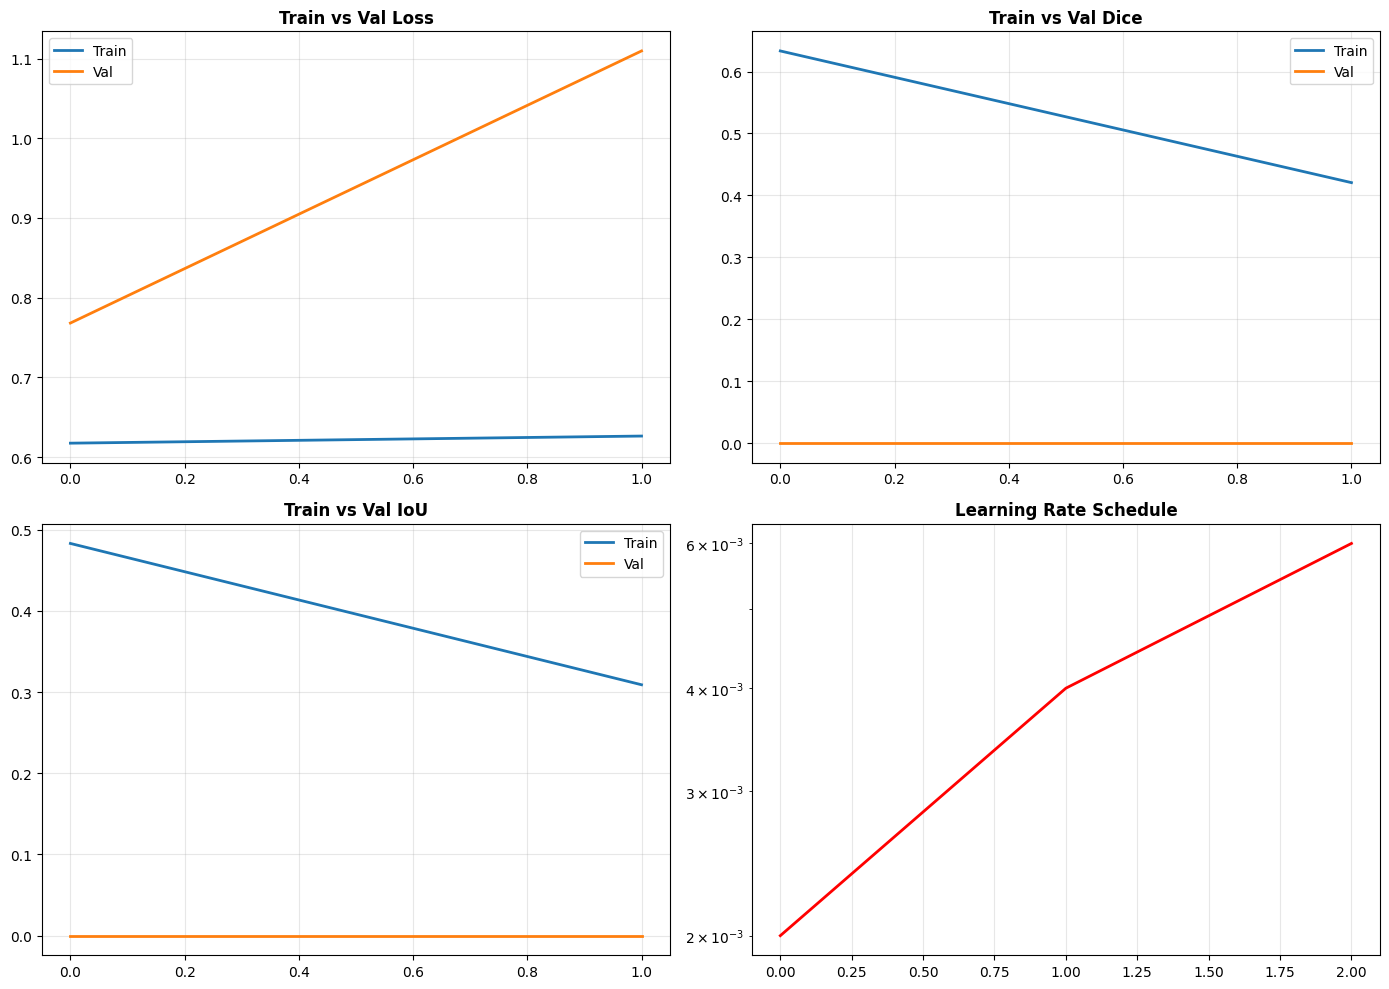

ValueError: All arrays must be of the same length

In [30]:
# ==============================================================================
# Cell 10: Plotting & Saving
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14,10))
for i, (k, lbl) in enumerate([('train_loss','Loss'), ('train_dice','Dice'), ('train_iou','IoU')]):
    row, col = divmod(i, 2)
    axes[row, col].plot(history[f'train_{k.split("_")[1]}'], label='Train', linewidth=2)
    axes[row, col].plot(history[f'val_{k.split("_")[1]}'], label='Val', linewidth=2)
    axes[row, col].set_title(f'Train vs Val {lbl}', fontweight='bold'); axes[row, col].legend(); axes[row, col].grid(True, alpha=0.3)
axes[1,1].plot(history['lrs'], c='red', linewidth=2); axes[1,1].set_title('Learning Rate Schedule', fontweight='bold')
axes[1,1].set_yscale('log'); axes[1,1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(config.OUTPUT_DIR, "metrics_ViT_2", "training_history.png"), dpi=150)
plt.show()
pd.DataFrame(history).to_csv(os.path.join(config.OUTPUT_DIR, "metrics_ViT_2", "training_history.csv"), index=False)
print("✅ Metrics saved")

In [31]:
# ==============================================================================
# Cell 11: Predictor (Handles Shapefiles for Evaluation)
# ==============================================================================
class SARPredictor:
    def __init__(self, path, device=DEVICE):
        self.device = device
        ckpt = torch.load(path, map_location=device, weights_only=False)
        self.model = ViTSegmentation(config.IMG_SIZE, 16, config.IN_CHANNELS, config.OUT_CHANNELS, 256, 6, 8).to(device)
        self.model.load_state_dict(ckpt['model_state_dict'])
        self.model.eval()
        self.transform = get_validation_augmentation()

    def predict(self, img_path, th=0.5):
        with rasterio.open(img_path) as src:
            bands = list(range(1, config.IN_CHANNELS+1))
            img = src.read(bands).transpose(1,2,0).astype(np.float32)
            if img.max() > 1.0: img /= 255.0
            # Resize to model input size if needed
            if img.shape[0] != config.IMG_SIZE or img.shape[1] != config.IMG_SIZE:
                from skimage.transform import resize
                img = resize(img, (config.IMG_SIZE, config.IMG_SIZE, config.IN_CHANNELS),
                           mode='reflect', anti_aliasing=True, preserve_range=True).astype(np.float32)
            profile = src.profile.copy()
            profile.update(width=config.IMG_SIZE, height=config.IMG_SIZE)

        t = self.transform(image=img)
        with torch.no_grad():
            out = torch.sigmoid(self.model(t['image'].unsqueeze(0).to(self.device))).cpu().numpy()[0,0]
        mask = (out > th).astype(np.uint8)
        return mask, out, profile

# Load best model
pred = SARPredictor(best_path)
val_imgs = [os.path.join(config.VAL_IMAGES, f) for f in val_files]
results = []

print(f"\n🔍 Evaluating {len(val_imgs)} validation images...")
for p in tqdm(val_imgs):
    mask, prob, profile = pred.predict(p)
    base = os.path.splitext(os.path.basename(p))[0]

    # Try to load ground truth shapefile and rasterize for evaluation
    shp_name = f"{base}.shp"
    gt_path = os.path.join(config.GROUND_TRUTH, shp_name)

    if os.path.exists(gt_path):
        try:
            with rasterio.open(p) as ref:
                gdf = gpd.read_file(gt_path)
                if gdf.crs != ref.crs:
                    gdf = gdf.to_crs(ref.crs)
                gt_mask = rasterize(
                    shapes=[(geom, 1) for geom in gdf.geometry if geom is not None],
                    out_shape=(config.IMG_SIZE, config.IMG_SIZE),
                    transform=rasterio.transform.from_bounds(0, 0, config.IMG_SIZE, config.IMG_SIZE, config.IMG_SIZE, config.IMG_SIZE),
                    fill=0, dtype='uint8'
                ).astype(np.float32)
                gt_mask = (gt_mask > 0.5).astype(np.float32)

            m = calculate_metrics(torch.from_numpy(mask.astype(np.float32)).unsqueeze(0).unsqueeze(0),
                                torch.from_numpy(gt_mask).unsqueeze(0).unsqueeze(0))
            results.append({'image': base, **m})
        except Exception as e:
            print(f"⚠️ Could not evaluate {base}: {e}")

    # Save prediction mask
    out_path = os.path.join(config.OUTPUT_DIR, "predictions_ViT_2", f"{base}_pred.tif")
    with rasterio.open(out_path, 'w', **profile, count=1, dtype='uint8') as dst:
        dst.write(mask, 1)

if results:
    df = pd.DataFrame(results)
    df.to_csv(os.path.join(config.OUTPUT_DIR, "metrics_ViT_2", "val_evaluation.csv"), index=False)
    print("\n📊 Validation Summary (Mean):")
    print(df.mean(numeric_only=True).round(4).to_string())
else:
    print("⚠️ No shapefiles found for metric calculation (predictions still saved).")


🔍 Evaluating 4 validation images...


  0%|          | 0/4 [00:01<?, ?it/s]


TypeError: rasterio.open() got multiple values for keyword argument 'count'

# V3

In [32]:
"""
SAR Water Segmentation using Vision Transformer (ViT)
======================================================

A complete pipeline for semantic segmentation of water bodies in SAR imagery
using a Vision Transformer architecture with shapefile-to-raster conversion.

Features:
- Dual-polarization SAR image processing
- Shapefile to raster mask conversion
- Vision Transformer encoder with upsampling decoder
- Mixed precision training with gradient accumulation
- Comprehensive metrics tracking and visualization
- Automated model checkpointing and early stopping

Author: Refactored for production use
"""

import os
import sys
import gc
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any
from dataclasses import dataclass, asdict
# import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.transform import resize

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Geospatial
import rasterio
from rasterio.features import rasterize
import geopandas as gpd

# Augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2

# warnings.filterwarnings('ignore')

In [33]:
# ============================================================================
# Configuration
# ============================================================================

@dataclass
class Config:
    """Training configuration parameters"""
    # Paths
    data_dir: str = "/content/drive/MyDrive/SAR_water_images_and_labels"
    output_dir: str = "/content/drive/MyDrive/SAR_water_images_and_labels/outputs_for_ViT_2"

    # Image parameters
    img_size: int = 512
    in_channels: int = 2  # SAR dual-pol (VV, VH)
    out_channels: int = 1  # Binary segmentation

    # Model architecture
    patch_size: int = 16
    embed_dim: int = 256
    depth: int = 6
    num_heads: int = 8
    mlp_ratio: float = 4.0

    # Training hyperparameters
    batch_size: int = 2
    accumulate_steps: int = 4  # Effective batch size = 8
    num_epochs: int = 100
    learning_rate: float = 1e-2
    weight_decay: float = 1e-5
    warmup_epochs: int = 5

    # Optimization
    lr_patience: int = 5
    lr_factor: float = 0.5
    lr_min: float = 1e-7
    early_stop_patience: int = 15

    # Training settings
    use_amp: bool = True  # Automatic Mixed Precision
    augment: bool = True
    save_best_only: bool = True
    num_workers: int = 2

    # Random seed
    seed: int = 42

    def __post_init__(self):
        """Create necessary directories after initialization"""
        self.train_images = os.path.join(self.data_dir, "images")
        self.train_masks = os.path.join(self.data_dir, "labels")
        self.val_images = os.path.join(self.data_dir, "images")
        self.val_masks = os.path.join(self.data_dir, "labels")
        self.test_images = os.path.join(self.data_dir, "images")
        self.ground_truth = os.path.join(self.data_dir, "labels")

        # Create output structure
        for subdir in ["", "checkpoints_ViT_2", "metrics_ViT_2", "predictions_ViT_2"]:
            os.makedirs(os.path.join(self.output_dir, subdir), exist_ok=True)


In [34]:
# ============================================================================
# Utility Functions
# ============================================================================

def set_seed(seed: int = 42):
    """Set random seeds for reproducibility"""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def get_device() -> torch.device:
    """Get available compute device"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"✅ Using device: {device}")
    if torch.cuda.is_available():
        print(f"   GPU: {torch.cuda.get_device_name(0)}")
    return device

In [35]:
# ============================================================================
# Data Augmentation
# ============================================================================

def get_training_augmentation() -> A.Compose:
    """SAR-optimized training augmentation pipeline"""
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.Affine(
            translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},
            scale={"x": (0.9, 1.1), "y": (0.9, 1.1)},
            rotate=(-15, 15),
            p=0.5
        ),
        A.OneOf([
            A.GaussNoise(var_limit=(0.01, 0.09), p=1),
            A.GaussianBlur(blur_limit=(3, 7), p=1),
        ], p=0.3),
        A.Normalize(mean=(0.5, 0.5), std=(0.5, 0.5)),
        ToTensorV2()
    ])


def get_validation_augmentation() -> A.Compose:
    """Validation augmentation (normalization only)"""
    return A.Compose([
        A.Normalize(mean=(0.5, 0.5), std=(0.5, 0.5)),
        ToTensorV2()
    ])

In [36]:
# ============================================================================
# Dataset
# ============================================================================

class SARWaterDataset(Dataset):
    """
    Dataset for SAR water segmentation with shapefile-to-raster conversion

    Converts vector shapefiles to raster masks on-the-fly, matching the
    spatial resolution and CRS of the input SAR imagery.
    """

    def __init__(
        self,
        image_dir: str,
        mask_dir: str,
        file_list: Optional[List[str]] = None,
        transform: Optional[A.Compose] = None,
        in_channels: int = 2,
        img_size: int = 512
    ):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.in_channels = in_channels
        self.img_size = img_size

        # Get list of image files
        if file_list is None:
            self.files = sorted([
                f for f in os.listdir(image_dir)
                if f.lower().endswith(('.tif', '.tiff', '.png', '.jpg', '.jpeg'))
            ])
        else:
            self.files = file_list

        # Index available shapefiles
        if os.path.exists(mask_dir):
            self.available_shapes = {
                os.path.splitext(f)[0]: f
                for f in os.listdir(mask_dir)
                if f.lower().endswith('.shp')
            }
        else:
            self.available_shapes = {}
            print(f"⚠️  Mask directory not found: {mask_dir}")

    def __len__(self) -> int:
        return len(self.files)

    def _rasterize_shapefile(
        self,
        shp_path: str,
        transform: Any,
        crs: Any,
        height: int,
        width: int
    ) -> np.ndarray:
        """
        Convert vector shapefile to binary raster mask

        Args:
            shp_path: Path to shapefile
            transform: Rasterio transform from reference image
            crs: Coordinate reference system
            height: Output height in pixels
            width: Output width in pixels

        Returns:
            Binary mask as float32 array
        """
        try:
            gdf = gpd.read_file(shp_path)

            # Reproject to match reference CRS
            if gdf.crs != crs:
                gdf = gdf.to_crs(crs)

            # Rasterize polygons
            mask = rasterize(
                shapes=[(geom, 1) for geom in gdf.geometry if geom is not None],
                out_shape=(height, width),
                transform=transform,
                fill=0,
                dtype='uint8'
            )

            return mask.astype(np.float32)

        except Exception as e:
            print(f"⚠️  Failed to rasterize {shp_path}: {e}")
            return np.zeros((height, width), dtype=np.float32)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Get image and mask pair

        Returns:
            Tuple of (image, mask) tensors
        """
        img_name = self.files[idx]
        img_path = os.path.join(self.image_dir, img_name)

        # Load SAR image
        with rasterio.open(img_path) as src:
            bands = list(range(1, self.in_channels + 1))
            image = src.read(bands).transpose(1, 2, 0).astype(np.float32)

            # Normalize to [0, 1]
            if image.max() > 1.0:
                image = image / 255.0

            # Store metadata for mask rasterization
            ref_transform = src.transform
            ref_crs = src.crs
            ref_height = src.height
            ref_width = src.width

        # Find and rasterize corresponding shapefile
        base_name = os.path.splitext(img_name)[0]
        shp_filename = self.available_shapes.get(base_name)

        if shp_filename:
            shp_path = os.path.join(self.mask_dir, shp_filename)
            mask = self._rasterize_shapefile(
                shp_path, ref_transform, ref_crs, ref_height, ref_width
            )
        else:
            print(f"⚠️  No shapefile found for {img_name}, using empty mask")
            mask = np.zeros((ref_height, ref_width), dtype=np.float32)

        # Resize to target size if needed
        if image.shape[0] != self.img_size or image.shape[1] != self.img_size:
            image = resize(
                image,
                (self.img_size, self.img_size, self.in_channels),
                mode='reflect',
                anti_aliasing=True,
                preserve_range=True
            ).astype(np.float32)

            mask = resize(
                mask,
                (self.img_size, self.img_size),
                order=0,
                mode='reflect',
                anti_aliasing=False,
                preserve_range=True
            ).astype(np.float32)

            # Re-binarize after resize
            mask = (mask > 0.5).astype(np.float32)

        # Apply transformations
        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image, mask = transformed['image'], transformed['mask']

        # Ensure mask has channel dimension
        if mask.dim() == 2:
            mask = mask.unsqueeze(0)

        return image, mask

In [37]:
# ============================================================================
# Vision Transformer Architecture
# ============================================================================

class PatchEmbedding(nn.Module):
    """Convert image to sequence of patch embeddings"""

    def __init__(
        self,
        img_size: int = 512,
        patch_size: int = 16,
        in_channels: int = 2,
        embed_dim: int = 256
    ):
        super().__init__()
        self.proj = nn.Conv2d(
            in_channels, embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # (B, C, H, W) -> (B, embed_dim, H/P, W/P) -> (B, N, embed_dim)
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class MultiHeadAttention(nn.Module):
    """Multi-head self-attention mechanism"""

    def __init__(
        self,
        dim: int,
        num_heads: int = 8,
        qkv_bias: bool = True,
        attn_drop: float = 0.0,
        proj_drop: float = 0.0
    ):
        super().__init__()
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, N, C = x.shape

        # Generate Q, K, V
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)

        # Scaled dot-product attention
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        # Apply attention to values
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)

        return x


class TransformerBlock(nn.Module):
    """Transformer encoder block with attention and MLP"""

    def __init__(
        self,
        dim: int,
        num_heads: int = 8,
        mlp_ratio: float = 4.0,
        qkv_bias: bool = True,
        drop: float = 0.0,
        attn_drop: float = 0.0
    ):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = MultiHeadAttention(dim, num_heads, qkv_bias, attn_drop, drop)
        self.norm2 = nn.LayerNorm(dim)

        mlp_hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_hidden),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(mlp_hidden, dim),
            nn.Dropout(drop)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Pre-norm architecture
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


class ViTEncoder(nn.Module):
    """Vision Transformer encoder"""

    def __init__(
        self,
        img_size: int = 512,
        patch_size: int = 16,
        in_channels: int = 2,
        embed_dim: int = 256,
        depth: int = 6,
        num_heads: int = 8
    ):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)

        num_patches = (img_size // patch_size) ** 2
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim))

        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio=4.0)
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)

        # Initialize positional embeddings
        nn.init.normal_(self.pos_embed, mean=0.0, std=0.02)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Patch embedding + positional encoding
        x = self.patch_embed(x) + self.pos_embed

        # Apply transformer blocks
        for block in self.blocks:
            x = block(x)

        x = self.norm(x)
        return x


class ViTSegmentation(nn.Module):
    """
    Vision Transformer for semantic segmentation

    Encoder: ViT with patch embeddings and transformer blocks
    Decoder: Upsampling CNN to restore spatial resolution
    """

    def __init__(
        self,
        img_size: int = 512,
        patch_size: int = 16,
        in_channels: int = 2,
        num_classes: int = 1,
        embed_dim: int = 256,
        depth: int = 6,
        num_heads: int = 8
    ):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size

        self.encoder = ViTEncoder(
            img_size, patch_size, in_channels, embed_dim, depth, num_heads
        )

        # Upsampling decoder
        self.head = nn.Sequential(
            nn.Conv2d(embed_dim, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.Conv2d(64, num_classes, kernel_size=1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B = x.shape[0]

        # Encode
        x = self.encoder(x)

        # Reshape to 2D feature map
        H = W = self.img_size // self.patch_size
        x = x.transpose(1, 2).reshape(B, -1, H, W)

        # Decode
        x = self.head(x)

        # Upsample to original size
        x = F.interpolate(
            x,
            size=(self.img_size, self.img_size),
            mode='bilinear',
            align_corners=True
        )

        return x

In [38]:
# ============================================================================
# Loss Functions
# ============================================================================

class DiceLoss(nn.Module):
    """Dice loss for binary segmentation"""

    def __init__(self, smooth: float = 1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        preds = torch.sigmoid(preds).view(-1)
        targets = targets.view(-1)

        intersection = (preds * targets).sum()
        dice = (2.0 * intersection + self.smooth) / (
            preds.sum() + targets.sum() + self.smooth
        )

        return 1 - dice


class BCEDiceLoss(nn.Module):
    """Combined Binary Cross Entropy and Dice Loss"""

    def __init__(self, bce_weight: float = 0.5, dice_weight: float = 0.5):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, preds: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        return (
            self.bce_weight * self.bce(preds, targets) +
            self.dice_weight * self.dice(preds, targets)
        )

In [39]:
# ============================================================================
# Metrics
# ============================================================================

def calculate_metrics(
    preds: torch.Tensor,
    targets: torch.Tensor,
    threshold: float = 0.5
) -> Dict[str, float]:
    """
    Calculate comprehensive segmentation metrics

    Returns:
        Dictionary with IoU, Dice, Precision, Recall, Specificity, Accuracy, F1
    """
    # Apply sigmoid if needed
    if preds.min() < 0 or preds.max() > 1:
        preds = torch.sigmoid(preds)

    # Binarize predictions
    preds_bin = (preds > threshold).float().view(-1)
    targets = targets.view(-1)

    # Calculate confusion matrix elements
    tp = (preds_bin * targets).sum()
    fp = (preds_bin * (1 - targets)).sum()
    fn = ((1 - preds_bin) * targets).sum()
    tn = ((1 - preds_bin) * (1 - targets)).sum()

    epsilon = 1e-7

    return {
        'iou': (tp + epsilon) / (tp + fp + fn + epsilon),
        'dice': (2 * tp + epsilon) / (2 * tp + fp + fn + epsilon),
        'precision': (tp + epsilon) / (tp + fp + epsilon),
        'recall': (tp + epsilon) / (tp + fn + epsilon),
        'specificity': (tn + epsilon) / (tn + fp + epsilon),
        'accuracy': (tp + tn + epsilon) / (tp + tn + fp + fn + epsilon),
        'f1_score': (
            2 * (tp + epsilon) / (tp + fp + epsilon) * (tp + epsilon) / (tp + fn + epsilon)
        ) / (
            (tp + epsilon) / (tp + fp + epsilon) + (tp + epsilon) / (tp + fn + epsilon) + epsilon
        )
    }

In [40]:
# ============================================================================
# Training Functions
# ============================================================================

def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    scaler: Optional[torch.cuda.amp.GradScaler],
    accumulate_steps: int
) -> Tuple[float, Dict[str, float]]:
    """
    Train model for one epoch

    Returns:
        Tuple of (average_loss, metrics_dict)
    """
    model.train()
    running_loss = 0.0
    metrics_sum = {k: 0.0 for k in [
        'iou', 'dice', 'precision', 'recall', 'specificity', 'accuracy', 'f1_score'
    ]}

    optimizer.zero_grad()
    pbar = tqdm(loader, desc="Training")

    for i, (images, masks) in enumerate(pbar):
        images, masks = images.to(device), masks.to(device)
        loss_scale = 1.0 / accumulate_steps

        # Forward pass with mixed precision
        if scaler:
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, masks) * loss_scale
            scaler.scale(loss).backward()
        else:
            outputs = model(images)
            loss = criterion(outputs, masks) * loss_scale
            loss.backward()

        # Optimizer step with gradient accumulation
        if (i + 1) % accumulate_steps == 0 or (i + 1) == len(loader):
            if scaler:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()
            optimizer.zero_grad()

        # Calculate metrics
        with torch.no_grad():
            batch_metrics = calculate_metrics(outputs.detach(), masks)
            for k in metrics_sum:
                metrics_sum[k] += batch_metrics[k]

        running_loss += loss.item() * accumulate_steps
        pbar.set_postfix(
            loss=loss.item() * accumulate_steps,
            dice=batch_metrics['dice']
        )

    avg_loss = running_loss / len(loader)
    avg_metrics = {k: v / len(loader) for k, v in metrics_sum.items()}

    return avg_loss, avg_metrics


def validate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device
) -> Tuple[float, Dict[str, float]]:
    """
    Validate model

    Returns:
        Tuple of (average_loss, metrics_dict)
    """
    model.eval()
    running_loss = 0.0
    metrics_sum = {k: 0.0 for k in [
        'iou', 'dice', 'precision', 'recall', 'specificity', 'accuracy', 'f1_score'
    ]}

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Validation"):
            images, masks = images.to(device), masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            batch_metrics = calculate_metrics(outputs, masks)
            for k in metrics_sum:
                metrics_sum[k] += batch_metrics[k]

            running_loss += loss.item()

    avg_loss = running_loss / len(loader)
    avg_metrics = {k: v / len(loader) for k, v in metrics_sum.items()}

    return avg_loss, avg_metrics


def lr_warmup(epoch: int, base_lr: float, warmup_epochs: int) -> float:
    """Calculate learning rate with linear warmup"""
    if epoch < warmup_epochs:
        return base_lr * (epoch + 1) / warmup_epochs
    return base_lr

In [41]:
# ============================================================================
# Prediction & Evaluation
# ============================================================================

class SARPredictor:
    """Predictor class for inference on SAR images"""

    def __init__(self, checkpoint_path: str, config: Config, device: torch.device):
        self.device = device
        self.config = config

        # Load checkpoint
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

        # Initialize model
        self.model = ViTSegmentation(
            config.img_size,
            config.patch_size,
            config.in_channels,
            config.out_channels,
            config.embed_dim,
            config.depth,
            config.num_heads
        ).to(device)

        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.model.eval()

        self.transform = get_validation_augmentation()

    def predict(
        self,
        img_path: str,
        threshold: float = 0.5
    ) -> Tuple[np.ndarray, np.ndarray, Dict]:
        """
        Predict water mask for input image

        Args:
            img_path: Path to input SAR image
            threshold: Binarization threshold

        Returns:
            Tuple of (binary_mask, probability_map, rasterio_profile)
        """
        # Load image
        with rasterio.open(img_path) as src:
            bands = list(range(1, self.config.in_channels + 1))
            image = src.read(bands).transpose(1, 2, 0).astype(np.float32)

            if image.max() > 1.0:
                image /= 255.0

            # Resize if needed
            if image.shape[0] != self.config.img_size or image.shape[1] != self.config.img_size:
                image = resize(
                    image,
                    (self.config.img_size, self.config.img_size, self.config.in_channels),
                    mode='reflect',
                    anti_aliasing=True,
                    preserve_range=True
                ).astype(np.float32)

            # Store profile for output
            profile = src.profile.copy()
            profile.update(
                width=self.config.img_size,
                height=self.config.img_size,
                count=1,
                dtype='uint8'
            )

        # Transform and predict
        transformed = self.transform(image=image)
        image_tensor = transformed['image'].unsqueeze(0).to(self.device)

        with torch.no_grad():
            output = self.model(image_tensor)
            prob_map = torch.sigmoid(output).cpu().numpy()[0, 0]

        binary_mask = (prob_map > threshold).astype(np.uint8)

        return binary_mask, prob_map, profile

In [42]:
# ============================================================================
# Visualization
# ============================================================================

def plot_training_history(history: Dict, output_dir: str):
    """Plot and save training metrics"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Loss
    axes[0, 0].plot(history['train_loss'], label='Train', linewidth=2)
    axes[0, 0].plot(history['val_loss'], label='Val', linewidth=2)
    axes[0, 0].set_title('Train vs Val Loss', fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Dice
    axes[0, 1].plot(history['train_dice'], label='Train', linewidth=2)
    axes[0, 1].plot(history['val_dice'], label='Val', linewidth=2)
    axes[0, 1].set_title('Train vs Val Dice', fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # IoU
    axes[1, 0].plot(history['train_iou'], label='Train', linewidth=2)
    axes[1, 0].plot(history['val_iou'], label='Val', linewidth=2)
    axes[1, 0].set_title('Train vs Val IoU', fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Learning Rate
    axes[1, 1].plot(history['lrs'], c='red', linewidth=2)
    axes[1, 1].set_title('Learning Rate Schedule', fontweight='bold')
    axes[1, 1].set_yscale('log')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "training_history.png"), dpi=150)
    plt.show()

In [43]:
# ============================================================================
# Main Training Pipeline
# ============================================================================

def main():
    """Main training and evaluation pipeline"""

    # Initialize configuration
    config = Config()

    # Set random seed
    set_seed(config.seed)

    # Get device
    device = get_device()

    print(f"\n{'='*70}")
    print(f"SAR Water Segmentation using Vision Transformer")
    print(f"{'='*70}")
    print(f"Configuration:")
    print(f"  Image Size: {config.img_size}x{config.img_size}")
    print(f"  Input Channels: {config.in_channels}")
    print(f"  Batch Size: {config.batch_size} (effective: {config.batch_size * config.accumulate_steps})")
    print(f"  Learning Rate: {config.learning_rate}")
    print(f"  Epochs: {config.num_epochs}")
    print(f"  Output: {config.output_dir}")
    print(f"{'='*70}\n")

    # ========================================================================
    # Data Preparation
    # ========================================================================

    print("📁 Preparing datasets...")

    # Get all image files
    all_files = sorted([
        f for f in os.listdir(config.train_images)
        if f.lower().endswith(('.tif', '.tiff', '.png', '.jpg', '.jpeg'))
    ])

    if not all_files:
        raise FileNotFoundError(f"No images found in {config.train_images}!")

    # Split train/val (80/20)
    rng = np.random.RandomState(config.seed)
    rng.shuffle(all_files)
    split_idx = int(0.8 * len(all_files))
    train_files = all_files[:split_idx]
    val_files = all_files[split_idx:]

    # Create datasets
    train_dataset = SARWaterDataset(
        config.train_images,
        config.train_masks,
        train_files,
        get_training_augmentation() if config.augment else get_validation_augmentation(),
        config.in_channels,
        config.img_size
    )

    val_dataset = SARWaterDataset(
        config.val_images,
        config.val_masks,
        val_files,
        get_validation_augmentation(),
        config.in_channels,
        config.img_size
    )

    # Create dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=config.num_workers,
        pin_memory=True,
        drop_last=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers,
        pin_memory=True
    )

    print(f"✅ Dataset split: {len(train_dataset)} train | {len(val_dataset)} val")

    # ========================================================================
    # Model Initialization
    # ========================================================================

    print("\n🔧 Initializing model...")

    model = ViTSegmentation(
        config.img_size,
        config.patch_size,
        config.in_channels,
        config.out_channels,
        config.embed_dim,
        config.depth,
        config.num_heads
    ).to(device)

    criterion = BCEDiceLoss()
    optimizer = Adam(
        model.parameters(),
        lr=config.learning_rate,
        weight_decay=config.weight_decay
    )
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=config.lr_factor,
        patience=config.lr_patience,
        min_lr=config.lr_min
    )

    scaler = (
        torch.cuda.amp.GradScaler()
        if config.use_amp and torch.cuda.is_available()
        else None
    )

    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"✅ Model initialized: {trainable_params:,} trainable parameters")

    # ========================================================================
    # Training Loop
    # ========================================================================

    print(f"\n🚀 Starting training...\n")

    history = {
        'train_loss': [], 'val_loss': [],
        'train_dice': [], 'val_dice': [],
        'train_iou': [], 'val_iou': [],
        'lrs': []
    }

    best_val_loss = float('inf')
    best_val_dice = 0.0
    no_improvement = 0
    best_checkpoint_path = os.path.join(
        config.output_dir, "checkpoints_ViT_2", "best_model.pth"
    )

    for epoch in range(config.num_epochs):
        # Learning rate warmup
        current_lr = lr_warmup(epoch, config.learning_rate, config.warmup_epochs)
        for param_group in optimizer.param_groups:
            param_group['lr'] = current_lr
        history['lrs'].append(current_lr)

        # Train
        train_loss, train_metrics = train_one_epoch(
            model, train_loader, criterion, optimizer, device, scaler, config.accumulate_steps
        )

        # Validate
        val_loss, val_metrics = validate(model, val_loader, criterion, device)

        # Update scheduler (after warmup)
        if epoch >= config.warmup_epochs:
            scheduler.step(val_loss)

        # Record history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_dice'].append(train_metrics['dice'])
        history['val_dice'].append(val_metrics['dice'])
        history['train_iou'].append(train_metrics['iou'])
        history['val_iou'].append(val_metrics['iou'])

        # Print epoch summary
        print(
            f"Epoch {epoch+1}/{config.num_epochs} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train Dice: {train_metrics['dice']:.4f} | Val Dice: {val_metrics['dice']:.4f}"
        )

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_dice = val_metrics['dice']
            no_improvement = 0

            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_dice': val_metrics['dice'],
                'config': asdict(config)
            }, best_checkpoint_path)

            print(f"  💾 Best model saved! Val Dice: {val_metrics['dice']:.4f}")
        else:
            no_improvement += 1

            if no_improvement >= config.early_stop_patience:
                print(f"\n🛑 Early stopping at epoch {epoch+1}")
                break

    # Clean up
    torch.cuda.empty_cache()
    gc.collect()

    print("\n✅ Training complete!")

    # ========================================================================
    # Save Metrics
    # ========================================================================

    print("\n📊 Saving training metrics...")

    metrics_dir = os.path.join(config.output_dir, "metrics_ViT_2")

    # Save plots
    plot_training_history(history, metrics_dir)

    # Save CSV
    pd.DataFrame(history).to_csv(
        os.path.join(metrics_dir, "training_history.csv"),
        index=False
    )

    print("✅ Metrics saved")

    # ========================================================================
    # Evaluation on Validation Set
    # ========================================================================

    print("\n🔍 Evaluating on validation set...")

    predictor = SARPredictor(best_checkpoint_path, config, device)
    val_image_paths = [os.path.join(config.val_images, f) for f in val_files]

    results = []
    predictions_dir = os.path.join(config.output_dir, "predictions_ViT_2")

    for img_path in tqdm(val_image_paths, desc="Predicting"):
        binary_mask, prob_map, profile = predictor.predict(img_path)
        base_name = os.path.splitext(os.path.basename(img_path))[0]

        # Try to load ground truth shapefile for evaluation
        shp_name = f"{base_name}.shp"
        gt_path = os.path.join(config.ground_truth, shp_name)

        if os.path.exists(gt_path):
            try:
                with rasterio.open(img_path) as ref:
                    gdf = gpd.read_file(gt_path)
                    if gdf.crs != ref.crs:
                        gdf = gdf.to_crs(ref.crs)

                    gt_mask = rasterize(
                        shapes=[(geom, 1) for geom in gdf.geometry if geom is not None],
                        out_shape=(config.img_size, config.img_size),
                        transform=rasterio.transform.from_bounds(
                            0, 0, config.img_size, config.img_size,
                            config.img_size, config.img_size
                        ),
                        fill=0,
                        dtype='uint8'
                    ).astype(np.float32)

                    gt_mask = (gt_mask > 0.5).astype(np.float32)

                    # Calculate metrics
                    metrics = calculate_metrics(
                        torch.from_numpy(binary_mask.astype(np.float32)).unsqueeze(0).unsqueeze(0),
                        torch.from_numpy(gt_mask).unsqueeze(0).unsqueeze(0)
                    )

                    results.append({'image': base_name, **metrics})
            except Exception as e:
                print(f"⚠️  Could not evaluate {base_name}: {e}")

        # Save prediction
        out_path = os.path.join(predictions_dir, f"{base_name}_pred.tif")
        with rasterio.open(out_path, 'w', **profile) as dst:
            dst.write(binary_mask, 1)

    # Save evaluation results
    if results:
        results_df = pd.DataFrame(results)
        results_df.to_csv(
            os.path.join(metrics_dir, "val_evaluation.csv"),
            index=False
        )

        print("\n📊 Validation Summary (Mean):")
        print(results_df.mean(numeric_only=True).round(4).to_string())
    else:
        print("⚠️  No shapefiles found for metric calculation (predictions still saved)")

    print(f"\n✅ Predictions saved to: {predictions_dir}")
    print(f"✅ All outputs saved to: {config.output_dir}")
    print("\n🎉 Pipeline complete!")



In [44]:

if __name__ == "__main__":
    main()

/tmp/ipykernel_15322/2027977407.py:18: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(0.01, 0.09), p=1),


✅ Using device: cpu

SAR Water Segmentation using Vision Transformer
Configuration:
  Image Size: 512x512
  Input Channels: 2
  Batch Size: 2 (effective: 8)
  Learning Rate: 0.01
  Epochs: 100
  Output: /content/drive/MyDrive/SAR_water_images_and_labels/outputs_for_ViT_2

📁 Preparing datasets...
✅ Dataset split: 16 train | 4 val

🔧 Initializing model...
✅ Model initialized: 5,501,825 trainable parameters

🚀 Starting training...



Training:   0%|          | 0/8 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Training:  38%|███▊      | 3/8 [00:35<00:59, 11.80s/it, dice=tensor(0.0334), loss=0.568]


KeyboardInterrupt: 